In [2]:
%pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

In [4]:
url = ('../data/raw/housing.csv')
df = pd.read_csv(url)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# Seleccionar solo las columnas necesarias: Latitude, Longitude, MedInc
columnas_necesarias = ['latitude', 'longitude', 'medinc']
df_selected = df[['Latitude', 'Longitude', 'MedInc']].copy() 

print(f"\n Columnas seleccionadas: {list(df_selected.columns)}")
print(f"\n Primeras 5 filas:")
print(df_selected.head())

print(f"\n Estadísticas descriptivas:")
print(df_selected.describe())

# Verificar valores nulos
print(f"\n Valores nulos por columna:")
print(df_selected.isnull().sum())

# Eliminar valores nulos si existen
df_selected = df_selected.dropna()
print(f"\n Dataset limpio: {df_selected.shape[0]} filas")


 Columnas seleccionadas: ['Latitude', 'Longitude', 'MedInc']

 Primeras 5 filas:
   Latitude  Longitude  MedInc
0     37.88    -122.23  8.3252
1     37.86    -122.22  8.3014
2     37.85    -122.24  7.2574
3     37.85    -122.25  5.6431
4     37.85    -122.25  3.8462

 Estadísticas descriptivas:
           Latitude     Longitude        MedInc
count  20640.000000  20640.000000  20640.000000
mean      35.631861   -119.569704      3.870671
std        2.135952      2.003532      1.899822
min       32.540000   -124.350000      0.499900
25%       33.930000   -121.800000      2.563400
50%       34.260000   -118.490000      3.534800
75%       37.710000   -118.010000      4.743250
max       41.950000   -114.310000     15.000100

 Valores nulos por columna:
Latitude     0
Longitude    0
MedInc       0
dtype: int64

 Dataset limpio: 20640 filas


# DIVISIÓN EN TRAIN Y TEST

In [6]:
# Separar características (X) 
X = df_selected[['Latitude', 'Longitude', 'MedInc']].values

# Dividir en train (80%) y test (20%)
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"\n Conjunto de entrenamiento: {X_train.shape[0]} casas")
print(f" Conjunto de prueba: {X_test.shape[0]} casas")


 Conjunto de entrenamiento: 16512 casas
 Conjunto de prueba: 4128 casas


# CONSTRUIR K-MEANS

In [7]:
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Entrenar el modelo con datos de entrenamiento
kmeans.fit(X_train)

print(f"\n Modelo K-Means entrenado con {n_clusters} clusters")

# Predecir clusters para el conjunto de entrenamiento
clusters_train = kmeans.predict(X_train)

# Añadir columna de cluster al dataframe de entrenamiento
df_train = pd.DataFrame(X_train, columns=['Latitude', 'Longitude', 'MedInc'])
df_train['cluster'] = clusters_train

print(f"\n Distribución de casas por cluster (entrenamiento):")
print(df_train['cluster'].value_counts().sort_index())

# Obtener las coordenadas de los centroides y mostrar resultados
centroides = kmeans.cluster_centers_
print(f"\n Coordenadas de los centroides:")
for i, centroid in enumerate(centroides):
    print(f"  Cluster {i}: Lat={centroid[0]:.2f}, Long={centroid[1]:.2f}, MedInc={centroid[2]:.2f}")



 Modelo K-Means entrenado con 6 clusters

 Distribución de casas por cluster (entrenamiento):
cluster
0    1348
1     342
2    5628
3    3024
4    3919
5    2251
Name: count, dtype: int64

 Coordenadas de los centroides:
  Cluster 0: Lat=36.06, Long=-119.72, MedInc=2.69
  Cluster 1: Lat=35.18, Long=-119.53, MedInc=11.13
  Cluster 2: Lat=33.82, Long=-117.83, MedInc=2.89
  Cluster 3: Lat=33.86, Long=-118.02, MedInc=5.59
  Cluster 4: Lat=38.35, Long=-121.89, MedInc=2.82
  Cluster 5: Lat=37.70, Long=-121.96, MedInc=5.51


# VISUALIZACIÓN DE LOS CLUSTERS 

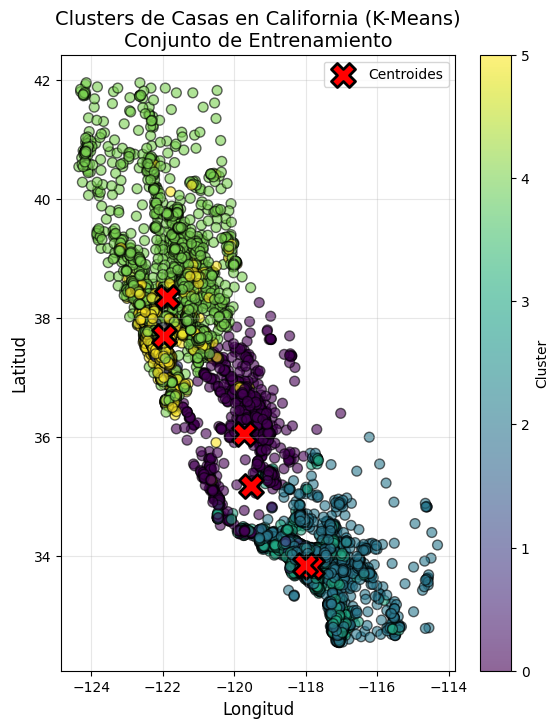

In [8]:
plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
scatter = plt.scatter(df_train['Longitude'], df_train['Latitude'], 
                     c=df_train['cluster'], cmap='viridis', 
                     alpha=0.6, edgecolors='k', s=50)
plt.scatter(centroides[:, 1], centroides[:, 0], 
           c='red', marker='X', s=300, edgecolors='black', 
           linewidths=2, label='Centroides')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.title('Clusters de Casas en California (K-Means)\nConjunto de Entrenamiento', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)

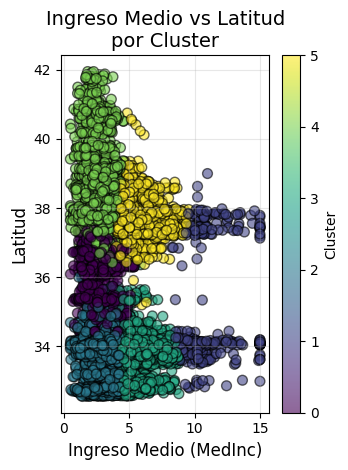

In [9]:
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(df_train['MedInc'], df_train['Latitude'], 
                      c=df_train['cluster'], cmap='viridis', 
                      alpha=0.6, edgecolors='k', s=50)
plt.xlabel('Ingreso Medio (MedInc)', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.title('Ingreso Medio vs Latitud\npor Cluster', fontsize=14)
plt.colorbar(scatter2, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# PREDECIR CON EL CONJUNTO DE TEST

In [10]:
# Predecir clusters para el conjunto de test
clusters_test = kmeans.predict(X_test)

# Crear dataframe para test
df_test = pd.DataFrame(X_test, columns=['Latitude', 'Longitude', 'MedInc'])
df_test['cluster'] = clusters_test

print(f"\n Distribución de casas por cluster (prueba):")
print(df_test['cluster'].value_counts().sort_index())



 Distribución de casas por cluster (prueba):
cluster
0     338
1      89
2    1488
3     736
4     957
5     520
Name: count, dtype: int64


# VISUALIZACIÓN COMPARATIVA: TRAIN + TEST

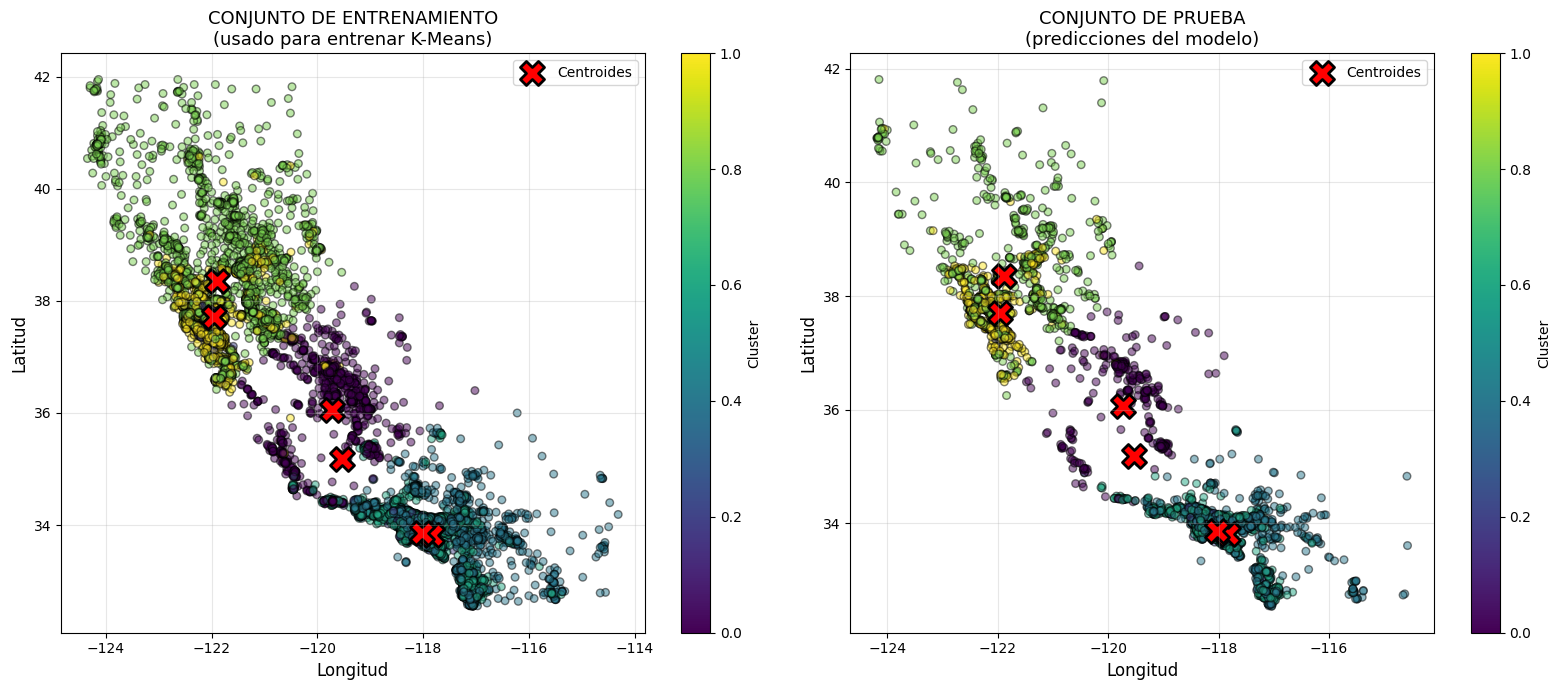


 Observación: Los clusters en TEST siguen patrones similares a TRAIN.
   Esto indica que el K-Means generalizó bien.


In [11]:
plt.figure(figsize=(16, 7))

# Gráfico de entrenamiento
plt.subplot(1, 2, 1)
plt.scatter(df_train['Longitude'], df_train['Latitude'], 
           c=df_train['cluster'], cmap='viridis', 
           alpha=0.5, edgecolors='k', s=30)
plt.scatter(centroides[:, 1], centroides[:, 0], 
           c='red', marker='X', s=300, edgecolors='black', 
           linewidths=2, label='Centroides')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.title('CONJUNTO DE ENTRENAMIENTO\n(usado para entrenar K-Means)', fontsize=13)
plt.colorbar(label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de test
plt.subplot(1, 2, 2)
plt.scatter(df_test['Longitude'], df_test['Latitude'], 
           c=df_test['cluster'], cmap='viridis', 
           alpha=0.5, edgecolors='k', s=30)
plt.scatter(centroides[:, 1], centroides[:, 0], 
           c='red', marker='X', s=300, edgecolors='black', 
           linewidths=2, label='Centroides')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.title('CONJUNTO DE PRUEBA\n(predicciones del modelo)', fontsize=13)
plt.colorbar(label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Observación: Los clusters en TEST siguen patrones similares a TRAIN.")
print("   Esto indica que el K-Means generalizó bien.")

Este gráfico muestra cómo K-Means agrupó las casas de California en 6 clusters según su ubicación. El gráfico de la izquierda es donde el modelo aprendió, y el de la derecha demuestra que funciona con datos nuevos. Como se ven iguales, el modelo es exitoso.

# ENTRENAR MODELO DE CLASIFICACIÓN SUPERVISADA

In [12]:
y_train = clusters_train
y_test = clusters_test

# Crear y entrenar un árbol de decisión
modelo_supervisado = DecisionTreeClassifier(max_depth=10, random_state=42)
modelo_supervisado.fit(X_train, y_train)

print("\n Modelo Decision Tree entrenado")

# Hacer predicciones
y_pred = modelo_supervisado.predict(X_test)

# EVALUACIÓN DEL MODELO
print("EVALUACIÓN DEL MODELO SUPERVISADO")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Accuracy (Exactitud): {accuracy:.2%}")

# Reporte de clasificación
print("\n Reporte de Clasificación:")
print(classification_report(y_test, y_pred))


 Modelo Decision Tree entrenado
EVALUACIÓN DEL MODELO SUPERVISADO

 Accuracy (Exactitud): 99.44%

 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       338
           1       1.00      0.98      0.99        89
           2       1.00      1.00      1.00      1488
           3       1.00      0.99      1.00       736
           4       0.99      0.99      0.99       957
           5       0.99      0.99      0.99       520

    accuracy                           0.99      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128



In [14]:
import os

os.makedirs('modelos', exist_ok=True)

# Guardar modelo K-Means
with open('modelos/modelo_kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print(" Modelo K-Means guardado: modelos/modelo_kmeans.pkl")

# Guardar modelo Decision Tree
with open('modelos/modelo_decision_tree.pkl', 'wb') as f:
    pickle.dump(modelo_supervisado, f)
print(" Modelo Decision Tree guardado: modelos/modelo_decision_tree.pkl")

 Modelo K-Means guardado: modelos/modelo_kmeans.pkl
 Modelo Decision Tree guardado: modelos/modelo_decision_tree.pkl
